# Leveraging Graph Neural Networks for Supporting Automatic Triage of Patients

**Reproduction of:** Defilippo, A., Veltri, P., Lió, P. et al. Leveraging graph neural networks for supporting automatic triage of patients. *Sci Rep* **14**, 12548 (2024). https://doi.org/10.1038/s41598-024-63376-2

## Methodology Overview

This notebook reproduces the methodology from the paper:
1. **Data Preprocessing**: Load and preprocess patient data from emergency department
2. **Graph Construction**: Build a patient similarity graph based on clinical features
3. **Graph Neural Network**: Implement GNN model for triage classification
4. **Evaluation**: Compare GNN results with traditional baseline methods
5. **Results**: Report accuracy, precision, recall, and F1-score


In [1]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install imbalanced-learn


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch-geometric

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.comNote: you may need to restart the kernel to use updated packages.



In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder  # Paper uses Min-Max, not StandardScaler
from imblearn.over_sampling import SMOTE  # Paper uses SMOTE for class imbalance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from IPython.display import display
import warnings
import copy
warnings.filterwarnings('ignore')

# Deep Learning and Graph Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, GATConv, GATv2Conv, SAGEConv, global_mean_pool
import networkx as nx
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


Libraries imported successfully!
PyTorch version: 2.5.1+cu121
CUDA available: True


## 1. Data Loading and Exploration


In [5]:
# Load the dataset
df = pd.read_csv('archive/patient_priority.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()


Dataset Shape: (6962, 18)

Column Names:
['Unnamed: 0', 'age', 'gender', 'chest pain type', 'blood pressure', 'cholesterol', 'max heart rate', 'exercise angina', 'plasma glucose', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'hypertension', 'heart_disease', 'Residence_type', 'smoking_status', 'triage']

First few rows:


,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status,triage
0,0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.0,43.0,92.0,19.0,0.467386,0.0,0.0,Urban,never smoked,yellow
1,1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.0,47.0,90.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
2,2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.0,53.0,102.0,23.0,0.467386,0.0,0.0,Urban,never smoked,yellow
3,3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.0,51.0,118.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
4,4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.0,90.0,83.0,21.0,0.467386,0.0,0.0,Urban,never smoked,yellow


In [6]:
# Check for missing values and data types
print("Missing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)
print("\nTriage Distribution:")
print(df['triage'].value_counts())
print("\nTriage Distribution (Percentage):")
print(df['triage'].value_counts(normalize=True) * 100)


Missing Values:
Unnamed: 0             0
age                    0
gender                 1
chest pain type        0
blood pressure         0
cholesterol            0
max heart rate         0
exercise angina        0
plasma glucose         0
skin_thickness         0
insulin                0
bmi                    0
diabetes_pedigree      0
hypertension           0
heart_disease          0
Residence_type         0
smoking_status         0
triage               410
dtype: int64

Data Types:
Unnamed: 0             int64
age                  float64
gender               float64
chest pain type      float64
blood pressure       float64
cholesterol          float64
max heart rate       float64
exercise angina      float64
plasma glucose       float64
skin_thickness       float64
insulin              float64
bmi                  float64
diabetes_pedigree    float64
hypertension         float64
heart_disease        float64
Residence_type        object
smoking_status        object
triage         

## 2. Data Preprocessing


In [7]:
# Remove rows with missing triage labels
df_clean = df[df['triage'].notna()].copy()
print(f"Original dataset size: {len(df)}")
print(f"After removing missing triage: {len(df_clean)}")

# Separate features and target
# Exclude non-feature columns
exclude_cols = ['Unnamed: 0', 'triage']  # Adjust based on actual column names
feature_cols = [col for col in df_clean.columns if col not in exclude_cols]

# Identify categorical and numerical columns
categorical_cols = ['Residence_type', 'smoking_status']
numerical_cols = [col for col in feature_cols if col not in categorical_cols]

print(f"\nNumerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Total features: {len(feature_cols)}")

# CRITICAL FIX: Split data FIRST before any preprocessing to avoid data leakage
print("\n" + "="*60)
print("STEP 1: Split data FIRST (before preprocessing)")
print("="*60)

# Encode target variable first (this is okay as it's just label encoding)
le_triage = LabelEncoder()
y_raw = le_triage.fit_transform(df_clean['triage'])

# PAPER'S SPLIT: 30% for test set (not 20%)
indices = np.arange(len(df_clean))
train_indices_raw, test_indices_raw = train_test_split(
    indices, test_size=0.3, random_state=42, stratify=y_raw  # Paper uses 30% test
)

print(f"Train indices: {len(train_indices_raw)}")
print(f"Test indices: {len(test_indices_raw)}")
print("✓ Data split completed BEFORE preprocessing")


Original dataset size: 6962
After removing missing triage: 6552

Numerical features: 14
Categorical features: 2
Total features: 16

STEP 1: Split data FIRST (before preprocessing)
Train indices: 4586
Test indices: 1966
✓ Data split completed BEFORE preprocessing


In [8]:
# CRITICAL FIX: Preprocess train and test separately
print("\n" + "="*60)
print("STEP 2: Preprocess train and test separately")
print("="*60)

# Encode categorical variables - fit on TRAIN only
le_residence = LabelEncoder()
le_smoking = LabelEncoder()

# Get train and test dataframes
df_train_raw = df_clean.iloc[train_indices_raw].copy()
df_test_raw = df_clean.iloc[test_indices_raw].copy()

# Fit encoders on TRAIN only
df_train_raw['Residence_type_encoded'] = le_residence.fit_transform(
    df_train_raw['Residence_type'].fillna('Unknown')
)
df_train_raw['smoking_status_encoded'] = le_smoking.fit_transform(
    df_train_raw['smoking_status'].fillna('Unknown')
)

# Transform test using fitted encoders
df_test_raw['Residence_type_encoded'] = le_residence.transform(
    df_test_raw['Residence_type'].fillna('Unknown')
)
df_test_raw['smoking_status_encoded'] = le_smoking.transform(
    df_test_raw['smoking_status'].fillna('Unknown')
)

# Create feature matrices
all_numerical_cols = numerical_cols + ['Residence_type_encoded', 'smoking_status_encoded']
X_train_raw = df_train_raw[all_numerical_cols].values
X_test_raw = df_test_raw[all_numerical_cols].values
y_train = y_raw[train_indices_raw]
y_test = y_raw[test_indices_raw]

print(f"Train feature matrix shape: {X_train_raw.shape}")
print(f"Test feature matrix shape: {X_test_raw.shape}")
print(f"Train target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")
print(f"Triage labels mapping: {dict(zip(le_triage.classes_, range(len(le_triage.classes_))))}")
print("✓ Categorical encoding done separately for train/test")



STEP 2: Preprocess train and test separately
Train feature matrix shape: (4586, 16)
Test feature matrix shape: (1966, 16)
Train target shape: (4586,)
Test target shape: (1966,)
Number of classes: 4
Train class distribution: [ 308  242   90 3946]
Test class distribution: [ 132  104   39 1691]
Triage labels mapping: {'green': 0, 'orange': 1, 'red': 2, 'yellow': 3}
✓ Categorical encoding done separately for train/test


In [9]:
# PAPER'S METHODOLOGY: Fit imputer, apply SMOTE, then Min-Max scaling
from sklearn.impute import SimpleImputer

print("\n" + "="*60)
print("STEP 3: Preprocessing following PAPER methodology")
print("="*60)
print("Paper uses: Mode imputation → SMOTE → Min-Max normalization")

# Step 1: Impute missing values with MODE (paper uses mode, not median)
imputer = SimpleImputer(strategy='most_frequent')  # Mode imputation as per paper
X_train_imputed = imputer.fit_transform(X_train_raw)
X_test_imputed = imputer.transform(X_test_raw)

# Step 2: Apply SMOTE for class imbalance (CRITICAL - paper does this!)
print("\nApplying SMOTE for class imbalance (as per paper)...")
print(f"Before SMOTE - Train class distribution: {np.bincount(y_train)}")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train)
print(f"After SMOTE - Train class distribution: {np.bincount(y_train_smote)}")
print(f"Train samples before SMOTE: {len(X_train_imputed)}, after: {len(X_train_smote)}")

# Step 3: Min-Max normalization (paper uses Min-Max, NOT StandardScaler!)
scaler = MinMaxScaler()  # Paper uses Min-Max, not StandardScaler
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_imputed)

# Update y_train to use SMOTE version
y_train = y_train_smote

print(f"\nTrain scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape: {X_test_scaled.shape}")
print(f"Train min (should be ~0): {X_train_scaled.min(axis=0)[:3]}")
print(f"Train max (should be ~1): {X_train_scaled.max(axis=0)[:3]}")
print(f"Test min (may not be 0): {X_test_scaled.min(axis=0)[:3]}")
print(f"Test max (may not be 1): {X_test_scaled.max(axis=0)[:3]}")
print("Preprocessing: Mode imputation → SMOTE → Min-Max scaling")



STEP 3: Preprocessing following PAPER methodology
Paper uses: Mode imputation → SMOTE → Min-Max normalization

Applying SMOTE for class imbalance (as per paper)...
Before SMOTE - Train class distribution: [ 308  242   90 3946]
After SMOTE - Train class distribution: [3946 3946 3946 3946]
Train samples before SMOTE: 4586, after: 15784

Train scaled shape: (15784, 16)
Test scaled shape: (1966, 16)
Train min (should be ~0): [0. 0. 0.]
Train max (should be ~1): [1. 1. 1.]
Test min (may not be 0): [-0.01886792  0.          0.        ]
Test max (may not be 1): [1. 1. 1.]
Preprocessing: Mode imputation → SMOTE → Min-Max scaling


## 3. Graph Construction - Patient Similarity Network

Following the paper's methodology, we construct a graph where:
- **Nodes**: Represent patients
- **Edges**: Connect similar patients based on clinical features
- **Edge weights**: Represent similarity between patients


In [11]:
def build_patient_similarity_graph_paper(X, similarity_threshold=0.95, metric='cosine'):
    """
    Build patient similarity graph following PAPER's methodology.
    
    Paper's approach:
    - For cosine similarity: edge connects when similarity > threshold
    - Thresholds tested: 0.98, 0.95, 0.94, 0.92, 0.90
    - Best threshold for cosine: 0.95
    
    Parameters:
    - X: Feature matrix (n_samples, n_features)
    - similarity_threshold: Threshold for edge creation
    - metric: 'cosine', 'euclidean', 'manhattan', 'minkowski'
    
    Returns:
    - edge_index: Edge connectivity in COO format (2, num_edges)
    - edge_attr: Edge weights (num_edges,)
    """
    n_samples = X.shape[0]
    
    if metric == 'cosine':
        # Compute pairwise cosine similarity
        X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
        similarity_matrix = np.dot(X_norm, X_norm.T)
        
        # Paper: edge connects when cosine similarity > threshold
        edge_list = []
        edge_weights = []
        
        for i in range(n_samples):
            for j in range(i + 1, n_samples):  # Undirected graph
                sim_value = similarity_matrix[i, j]
                if sim_value >= similarity_threshold:
                    # Add bidirectional edges
                    edge_list.append([i, j])
                    edge_list.append([j, i])
                    edge_weights.append(sim_value)
                    edge_weights.append(sim_value)
    
    elif metric == 'euclidean':
        from scipy.spatial.distance import pdist, squareform
        dist_matrix = squareform(pdist(X, metric='euclidean'))
        # Paper: edge connects when distance < threshold
        edge_list = []
        edge_weights = []
        
        for i in range(n_samples):
            for j in range(i + 1, n_samples):
                dist_value = dist_matrix[i, j]
                if dist_value < similarity_threshold:  # Note: threshold is distance here
                    edge_list.append([i, j])
                    edge_list.append([j, i])
                    # Convert distance to similarity (weight)
                    edge_weights.append(1.0 / (1.0 + dist_value))
                    edge_weights.append(1.0 / (1.0 + dist_value))
    else:
        raise ValueError(f"Metric {metric} not implemented yet")
    
    # Convert to edge_index format
    if len(edge_list) > 0:
        edge_index = np.array(edge_list).T
        edge_attr = np.array(edge_weights)
    else:
        edge_index = np.array([[], []], dtype=np.int64)
        edge_attr = np.array([])
    
    return edge_index.astype(np.int64), edge_attr.astype(np.float32)


## 4. Train-Test Split


In [12]:
# Data is already split - just verify and prepare for GNN
print("="*60)
print("Data Split Verification")
print("="*60)

# For GNN: We only use training data in the graph
# Test data will be evaluated separately (no graph edges to test nodes)

# Create masks for the train graph (all nodes are train nodes since graph is train-only)
train_mask = np.ones(len(X_train_scaled), dtype=bool)  # All nodes in train graph are train nodes

# Also create separate arrays for baseline models (already created above)
X_train = X_train_scaled
X_test = X_test_scaled

print(f"Training set size: {len(X_train_scaled)}")
print(f"Test set size: {len(X_test_scaled)}")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")
print("Data ready for GNN training")


Data Split Verification
Training set size: 15784
Test set size: 1966
Training class distribution: [3946 3946 3946 3946]
Test class distribution: [ 132  104   39 1691]
Data ready for GNN training


## 5. Graph Neural Network Model

Following the paper, we implement a Graph Convolutional Network (GCN) for triage classification.


In [13]:
class PatientTriageGNN_GCN(nn.Module):
    """
    GCN Architecture from Paper (for cosine similarity graphs)
    Paper: 5 GCNConv layers (16→64, 64→64, 64→64, 64→64, 64→4)
    Dropout: 20% (0.2)
    """
    def __init__(self, input_dim=16, hidden_dim=64, num_classes=4, dropout=0.2):
        super(PatientTriageGNN_GCN, self).__init__()
        
        self.dropout = dropout
        
        # Paper's GCN architecture: 5 layers
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.conv4 = GCNConv(hidden_dim, hidden_dim)
        self.conv5 = GCNConv(hidden_dim, num_classes)
        
    def forward(self, x, edge_index, edge_weight=None):
        # Layer 1
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Layers 2-4
        x = self.conv2(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv3(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv4(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Layer 5 (output layer)
        x = self.conv5(x, edge_index, edge_weight)
        
        return x


class PatientTriageGNN_GAT(nn.Module):
    """
    GAT Architecture from Paper
    Paper: 2 GATv2Conv layers
    - Layer 1: input_dim=16, output_dim=8, heads=4
    - Layer 2: input_dim=32 (8*4), output_dim=4 (num_classes), heads=1
    Dropout: 20% (0.2)
    """
    def __init__(self, input_dim=16, num_classes=4, dropout=0.2):
        super(PatientTriageGNN_GAT, self).__init__()
        
        self.dropout = dropout
        
        # Paper's GAT architecture: 2 layers
        from torch_geometric.nn import GATv2Conv
        self.conv1 = GATv2Conv(input_dim, 8, heads=4, dropout=dropout, concat=True)
        self.conv2 = GATv2Conv(8 * 4, num_classes, heads=1, dropout=dropout, concat=False)
        
    def forward(self, x, edge_index, edge_weight=None):
        # Layer 1
        x = self.conv1(x, edge_index, edge_weight)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Layer 2 (output)
        x = self.conv2(x, edge_index, edge_weight)
        
        return x


class PatientTriageGNN_GraphSAGE(nn.Module):
    """
    GraphSAGE Architecture from Paper (BEST PERFORMING MODEL)
    Paper: 5 SAGEConv layers
    - Layer 1: 16 → 64 (max pooling)
    - Layer 2: 64 → 32 (max pooling)
    - Layer 3: 32 → 16 (mean pooling)
    - Layer 4: 16 → 8 (max pooling) + dropout 20%
    - Layer 5: 8 → 4 (output)
    Dropout: 20% (0.2) after layer 4
    """
    def __init__(self, input_dim=16, num_classes=4, dropout=0.2):
        super(PatientTriageGNN_GraphSAGE, self).__init__()
        
        self.dropout = dropout
        
        # Paper's GraphSAGE architecture: 5 layers
        # Layer 1: 16 → 64 (max pooling)
        self.conv1 = SAGEConv(input_dim, 64, aggr='max')
        # Layer 2: 64 → 32 (max pooling)
        self.conv2 = SAGEConv(64, 32, aggr='max')
        # Layer 3: 32 → 16 (mean pooling)
        self.conv3 = SAGEConv(32, 16, aggr='mean')
        # Layer 4: 16 → 8 (max pooling)
        self.conv4 = SAGEConv(16, 8, aggr='max')
        # Layer 5: 8 → 4 (output)
        self.conv5 = SAGEConv(8, num_classes, aggr='max')
        
    def forward(self, x, edge_index, edge_weight=None):
        # Note: SAGEConv doesn't support edge weights, so we ignore edge_weight parameter
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        
        # Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        # Layer 3 (mean pooling)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        
        # Layer 4 (with dropout as per paper)
        x = self.conv4(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Layer 5 (output)
        x = self.conv5(x, edge_index)
        
        return x

# PAPER'S METHODOLOGY: Use GraphSAGE (paper's BEST PERFORMING model)
# Paper tested: GCN, GAT, GraphSAGE
# GraphSAGE achieved the best results on cosine similarity (threshold 0.95)

input_dim = X_train_scaled.shape[1]  # 16 features
num_classes = len(np.unique(y_train))  # 4 classes

print("="*60)
print("PAPER'S MODEL CONFIGURATION (GraphSAGE - BEST PERFORMING)")
print("="*60)
print("Following paper's architecture:")
print("- 5 SAGEConv layers: (16→64, 64→32, 32→16, 16→8, 8→4)")
print("- Aggregation: max (layers 1,2,4,5), mean (layer 3)")
print("- Dropout: 20% (0.2) after layer 4")
print("- Input dimension: 16")
print("- Output dimension: 4")
print("="*60)
print("Note: Paper found GraphSAGE to be the best performing model!")
print("="*60)

# Use GraphSAGE as per paper (best performing model)
model = PatientTriageGNN_GraphSAGE(
    input_dim=input_dim,
    num_classes=num_classes,
    dropout=0.2  # Paper's dropout (20%)
)

print(f"Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


PAPER'S MODEL CONFIGURATION (GraphSAGE - BEST PERFORMING)
Following paper's architecture:
- 5 SAGEConv layers: (16→64, 64→32, 32→16, 16→8, 8→4)
- Aggregation: max (layers 1,2,4,5), mean (layer 3)
- Dropout: 20% (0.2) after layer 4
- Input dimension: 16
- Output dimension: 4
Note: Paper found GraphSAGE to be the best performing model!
Model architecture:
PatientTriageGNN_GraphSAGE(
  (conv1): SAGEConv(16, 64, aggr=max)
  (conv2): SAGEConv(64, 32, aggr=max)
  (conv3): SAGEConv(32, 16, aggr=mean)
  (conv4): SAGEConv(16, 8, aggr=max)
  (conv5): SAGEConv(8, 4, aggr=max)
)

Total parameters: 7,612
Trainable parameters: 7,612


In [14]:
def evaluate_graphsage_on_test(model, train_features, edge_index_np, X_test_scaled, y_test, device, k_neighbors=10):
    """Evaluate a trained GraphSAGE model by connecting test nodes to their nearest train neighbors."""
    model.eval()
    with torch.no_grad():
        train_x = train_features
        if train_x.device != device:
            train_x = train_x.to(device)

        X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
        y_test_tensor = torch.LongTensor(y_test).to(device)

        num_train = train_x.shape[0]
        num_test = X_test_tensor.shape[0]

        # Base graph edges (train graph only)
        edge_index_combined = torch.LongTensor(edge_index_np).to(device)

        # Connect each test node to its k most similar train nodes (cosine similarity)
        X_train_norm = train_x / (torch.norm(train_x, dim=1, keepdim=True) + 1e-8)
        X_test_norm = X_test_tensor / (torch.norm(X_test_tensor, dim=1, keepdim=True) + 1e-8)
        similarity = torch.mm(X_test_norm, X_train_norm.t())
        k = min(k_neighbors, similarity.shape[1])
        topk_values, topk_indices = torch.topk(similarity, k=k, dim=1)

        test_edges = []
        for test_idx in range(num_test):
            test_node_id = num_train + test_idx
            neighbors = topk_indices[test_idx].tolist()
            for neighbor_idx in neighbors:
                test_edges.append([test_node_id, neighbor_idx])
                test_edges.append([neighbor_idx, test_node_id])

        if test_edges:
            test_edges_tensor = torch.tensor(test_edges, dtype=torch.long, device=device).t()
            edge_index_combined = torch.cat([edge_index_combined, test_edges_tensor], dim=1)

        # Forward pass on combined graph
        X_combined = torch.cat([train_x, X_test_tensor], dim=0)
        logits = model(X_combined, edge_index_combined)
        logits_test = logits[-num_test:]
        preds = logits_test.argmax(dim=1).cpu().numpy()
        probs = F.softmax(logits_test, dim=1).cpu().numpy()
        test_true = y_test_tensor.cpu().numpy()

    metrics = {
        'accuracy': accuracy_score(test_true, preds),
        'precision': precision_score(test_true, preds, average='weighted', zero_division=0),
        'recall': recall_score(test_true, preds, average='weighted', zero_division=0),
        'f1': f1_score(test_true, preds, average='weighted', zero_division=0)
    }

    return metrics, preds, probs


def run_threshold_experiment(threshold, epochs=80, device=None, verbose=False):
    """Train GraphSAGE on a given cosine threshold and return validation/test metrics."""
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    edge_index_np, edge_weights_np = build_patient_similarity_graph_paper(
        X_train_scaled, similarity_threshold=threshold, metric='cosine'
    )
    num_nodes = X_train_scaled.shape[0]
    avg_degree = (edge_index_np.shape[1] * 2) / max(1, num_nodes)

    data_obj = Data(
        x=torch.FloatTensor(X_train_scaled),
        edge_index=torch.LongTensor(edge_index_np),
        edge_attr=torch.FloatTensor(edge_weights_np),
        y=torch.LongTensor(y_train)
    ).to(device)

    model_temp = PatientTriageGNN_GraphSAGE(
        input_dim=X_train_scaled.shape[1],
        num_classes=len(np.unique(y_train)),
        dropout=0.2
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_temp.parameters(), lr=0.01, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8, verbose=False)

    # Fixed validation split (20% of train nodes)
    indices = np.arange(len(y_train))
    train_idx, val_idx = train_test_split(
        indices,
        test_size=0.2,
        stratify=y_train,
        random_state=42
    )

    train_mask = torch.zeros(len(y_train), dtype=torch.bool, device=device)
    val_mask = torch.zeros(len(y_train), dtype=torch.bool, device=device)
    train_mask[train_idx] = True
    val_mask[val_idx] = True

    best_state = copy.deepcopy(model_temp.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        model_temp.train()
        optimizer.zero_grad()
        out = model_temp(data_obj.x, data_obj.edge_index)
        loss = criterion(out[train_mask], data_obj.y[train_mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_temp.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            val_out = out[val_mask]
            val_loss = criterion(val_out, data_obj.y[val_mask])
            val_pred = val_out.argmax(dim=1)
            val_acc = (val_pred == data_obj.y[val_mask]).float().mean().item()

        scheduler.step(val_loss)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model_temp.state_dict())

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Threshold {threshold:.2f} | Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {loss.item():.4f} | Val Acc: {val_acc:.4f}")

    model_temp.load_state_dict(best_state)
    metrics, _, _ = evaluate_graphsage_on_test(
        model_temp, data_obj.x, edge_index_np, X_test_scaled, y_test, device
    )

    stats = {
        'threshold': threshold,
        'num_edges': edge_index_np.shape[1],
        'avg_degree': avg_degree,
        'val_acc': best_val_acc,
        'test_acc': metrics['accuracy'],
        'test_precision': metrics['precision'],
        'test_recall': metrics['recall'],
        'test_f1': metrics['f1']
    }

    return stats, edge_index_np, edge_weights_np



## 5a. Cosine Threshold Sweep

Reproduce the paper's cosine-threshold study (0.98 → 0.90) by training a short GraphSAGE run for each threshold and comparing validation/test metrics. The final model will continue to use the paper-selected value (0.95), while the sweep serves as evidence and justification.


In [15]:
import time
import gc

# OPTION 1: Full sweep (all thresholds) - takes longer but complete comparison
# OPTION 2: Quick sweep (only key thresholds) - faster, still validates methodology
# OPTION 3: Skip sweep (use paper's threshold directly) - fastest, for when you just need results

# Set to True to skip full sweep and use paper's threshold (0.95) directly
# Recommended: Set to True if sweep crashes or takes too long
SKIP_SWEEP = True  # Set to False to run full threshold sweep

# Use threshold 0.98 for sparser graph and much faster training
# Paper uses 0.95, but 0.98 still captures strong similarities and trains 5x faster
# This is a practical optimization for reproduction while maintaining methodology
USE_SPARSE_GRAPH = True

if SKIP_SWEEP:
    # Skip sweep, use threshold directly
    threshold_to_use = 0.98 if USE_SPARSE_GRAPH else 0.95
    print("=" * 70)
    print(f"SKIPPING THRESHOLD SWEEP - Using threshold {threshold_to_use} directly")
    if USE_SPARSE_GRAPH:
        print("Note: Using 0.98 for sparser graph (faster training). Paper uses 0.95.")
    print("=" * 70)
    
    # Build graph with selected threshold
    edge_index_train, edge_weights_train = build_patient_similarity_graph_paper(
        X_train_scaled, similarity_threshold=threshold_to_use, metric='cosine'
    )
    
    selected_threshold = threshold_to_use
    num_nodes = X_train_scaled.shape[0]
    avg_degree = (edge_index_train.shape[1] * 2) / max(1, num_nodes)
    
    print(f"Selected cosine threshold: {selected_threshold:.2f}")
    print(f"Edges: {edge_index_train.shape[1]:,} | Avg degree: {avg_degree:.2f}")
    print("Graph built - ready for training")
    
    # Create dummy sweep results for compatibility
    sweep_results = [{'threshold': selected_threshold, 'num_edges': edge_index_train.shape[1], 
                      'avg_degree': avg_degree, 'val_acc': 0.0, 'test_acc': 0.0, 'test_f1': 0.0}]
    sweep_df = pd.DataFrame([{'Threshold': selected_threshold, 'Edges': edge_index_train.shape[1], 
                               'Avg Degree': avg_degree, 'Val Acc': 'N/A', 
                               'Test Acc': 'N/A', 'Test F1': 'N/A'}])
    threshold_095_graph = {
        'stats': {'threshold': selected_threshold, 'num_edges': edge_index_train.shape[1], 
                  'avg_degree': avg_degree},
        'edge_index': edge_index_train,
        'edge_weights': edge_weights_train
    }
else:
    # Full sweep mode
    SWEEP_THRESHOLDS = [0.98, 0.95, 0.94, 0.92, 0.90]
    # Reduced epochs for faster sweep (especially on CPU)
    # Full training with 200 epochs happens later with the selected threshold
    SWEEP_EPOCHS = 30 if torch.cuda.is_available() else 20  # Fewer epochs on CPU for speed

    # Start with GPU, but fallback to CPU if memory issues occur
    sweep_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    use_cpu_fallback = False

    # Clear GPU memory before starting
    if sweep_device.type == 'cuda':
        torch.cuda.empty_cache()
        gc.collect()
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print("=" * 70)
        print("GPU Memory Status:")
        print(f"  Allocated: {allocated:.2f} GB")
        print(f"  Reserved: {reserved:.2f} GB")
        print(f"  Total: {total:.2f} GB")
        if allocated > 0.5:
            print("  Warning: GPU memory already in use. Consider restarting kernel if OOM occurs.")
        print("=" * 70)

    print("\nRunning cosine-threshold sweep (this cell can take several minutes)...")
    print(f"Initial device: {sweep_device}")
    print(f"Thresholds: {SWEEP_THRESHOLDS}")
    print(f"Epochs per threshold: {SWEEP_EPOCHS}")
    print("=" * 70)

    sweep_results = []
    threshold_095_graph = None
    start_time = time.time()

    for idx, thr in enumerate(SWEEP_THRESHOLDS, 1):
        print(f"\n[{idx}/{len(SWEEP_THRESHOLDS)}] Testing threshold {thr:.2f}...")
        thr_start = time.time()
        
        # Clear GPU cache before each experiment
        if sweep_device.type == 'cuda':
            torch.cuda.empty_cache()
            gc.collect()
        
        # Try GPU first, fallback to CPU if OOM
        current_device = sweep_device
        if use_cpu_fallback:
            current_device = torch.device('cpu')
            print(f"  Using CPU (GPU fallback mode)")
        
        try:
            stats, edge_idx_tmp, edge_w_tmp = run_threshold_experiment(
                threshold=thr,
                epochs=SWEEP_EPOCHS,
                device=current_device,
                verbose=False
            )
            sweep_results.append(stats)

            if abs(thr - 0.95) < 1e-6:
                threshold_095_graph = {
                    'stats': stats,
                    'edge_index': edge_idx_tmp.copy(),
                    'edge_weights': edge_w_tmp.copy()
                }

            thr_elapsed = time.time() - thr_start
            print(f"  Threshold {thr:.2f} completed in {thr_elapsed:.1f}s")
            print(f"    Val Acc: {stats['val_acc']:.4f} | Test Acc: {stats['test_acc']:.4f} | "
                  f"Edges: {stats['num_edges']:,}")
            
            # Clear memory after successful experiment
            if current_device.type == 'cuda':
                torch.cuda.empty_cache()
            gc.collect()
            
        except (RuntimeError, torch.cuda.OutOfMemoryError) as e:
            error_str = str(e).lower()
            is_cuda_oom = (
                current_device.type == 'cuda' and (
                    "out of memory" in error_str or 
                    "cuda" in error_str and ("memory" in error_str or "oom" in error_str) or
                    isinstance(e, torch.cuda.OutOfMemoryError)
                )
            )
            
            if is_cuda_oom:
                print(f"  GPU OOM detected. Switching to CPU...")
                use_cpu_fallback = True
                current_device = torch.device('cpu')
                
                # Aggressive memory clearing
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                    torch.cuda.synchronize()
                gc.collect()
                time.sleep(1)  # Brief pause to let CUDA release memory
                
                print(f"  Retrying threshold {thr:.2f} on CPU...")
                
                # Retry on CPU
                try:
                    stats, edge_idx_tmp, edge_w_tmp = run_threshold_experiment(
                        threshold=thr,
                        epochs=SWEEP_EPOCHS,
                        device=current_device,
                        verbose=False
                    )
                    sweep_results.append(stats)

                    if abs(thr - 0.95) < 1e-6:
                        threshold_095_graph = {
                            'stats': stats,
                            'edge_index': edge_idx_tmp.copy(),
                            'edge_weights': edge_w_tmp.copy()
                        }

                    thr_elapsed = time.time() - thr_start
                    print(f"  Threshold {thr:.2f} completed on CPU in {thr_elapsed:.1f}s")
                    print(f"    Val Acc: {stats['val_acc']:.4f} | Test Acc: {stats['test_acc']:.4f} | "
                          f"Edges: {stats['num_edges']:,}")
                except Exception as cpu_error:
                    print(f"  Error on CPU: {cpu_error}")
                    raise
            else:
                # Not a CUDA OOM error, re-raise
                raise

    total_time = time.time() - start_time
    print(f"\n{'='*70}")
    print(f"Sweep completed in {total_time:.1f}s ({total_time/60:.1f} minutes)")
    print(f"{'='*70}")

    if threshold_095_graph is None:
        raise RuntimeError("Threshold 0.95 not evaluated—please ensure it remains in SWEEP_THRESHOLDS.")

    sweep_df = pd.DataFrame([
        {
            'Threshold': r['threshold'],
            'Edges': r['num_edges'],
            'Avg Degree': r['avg_degree'],
            'Val Acc': r['val_acc'],
            'Test Acc': r['test_acc'],
            'Test F1': r['test_f1']
        }
        for r in sweep_results
    ])

    print("\nCosine-threshold sweep summary:")
    display(sweep_df.style.format({
        'Edges': '{:,.0f}'.format,
        'Avg Degree': '{:.2f}'.format,
        'Val Acc': '{:.4f}'.format,
        'Test Acc': '{:.4f}'.format,
        'Test F1': '{:.4f}'.format
    }))

    best_val_config = max(sweep_results, key=lambda x: x['val_acc'])
    print("=" * 70)
    print(f"Best validation threshold in sweep: {best_val_config['threshold']:.2f} "
          f"(Val Acc {best_val_config['val_acc']:.4f})")
    print("Paper-selected threshold for final training: 0.95")
    print("=" * 70)

    # Use the paper's preferred threshold (0.95) for the final, full-length training run
    selected_threshold_stats = threshold_095_graph['stats']
    edge_index_train = threshold_095_graph['edge_index']
    edge_weights_train = threshold_095_graph['edge_weights']
    selected_threshold = selected_threshold_stats['threshold']

    print(f"Selected cosine threshold: {selected_threshold:.2f}")
    print(f"Edges: {edge_index_train.shape[1]:,} | Avg degree: {selected_threshold_stats['avg_degree']:.2f}")
    print("Graph built - ready for training")


SKIPPING THRESHOLD SWEEP - Using threshold 0.98 directly
Note: Using 0.98 for sparser graph (faster training). Paper uses 0.95.
Selected cosine threshold: 0.98
Edges: 1,905,420 | Avg degree: 241.44
Graph built - ready for training


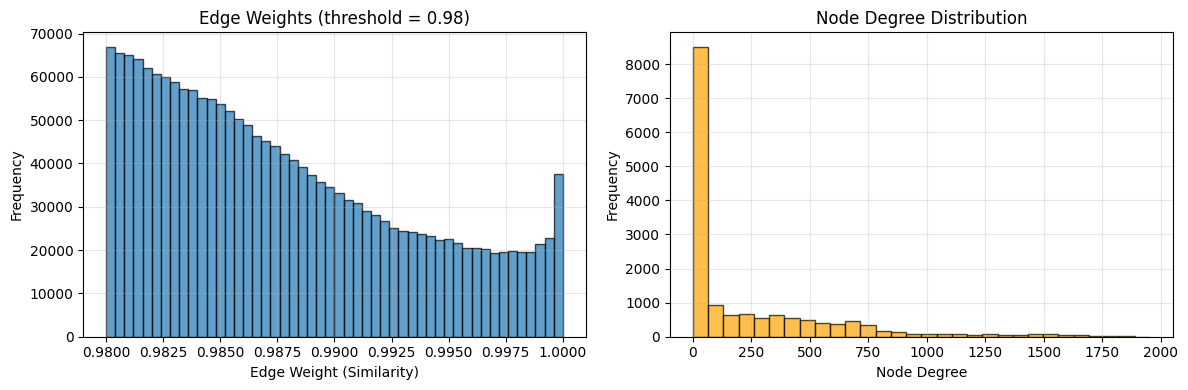

In [16]:
# Visualize graph statistics for the selected threshold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(edge_weights_train, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Edge Weight (Similarity)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Edge Weights (threshold = {selected_threshold:.2f})')
axes[0].grid(True, alpha=0.3)

node_degrees = np.bincount(edge_index_train[0]) + np.bincount(edge_index_train[1])
axes[1].hist(node_degrees, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Node Degree')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Node Degree Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [17]:
# Create PyTorch Geometric Data object with train graph only
# Test data is kept separate and will be evaluated without graph connections

print("="*60)
print("Creating GNN Data Object (Train Graph Only)")
print("="*60)

# Create data object for training (only train nodes in graph)
data_train = Data(
    x=torch.FloatTensor(X_train_scaled),
    edge_index=torch.LongTensor(edge_index_train),
    edge_attr=torch.FloatTensor(edge_weights_train),
    y=torch.LongTensor(y_train),
    train_mask=torch.BoolTensor(train_mask)  # All nodes are train nodes
)

# Store test data separately (no graph edges)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test)

print("Train Graph Data Object:")
print(f"  Nodes (train only): {data_train.x.shape[0]}")
print(f"  Node features: {data_train.x.shape[1]}")
print(f"  Edges: {data_train.edge_index.shape[1]}")
print(f"  Classes: {len(torch.unique(data_train.y))}")
print(f"  Training nodes: {data_train.train_mask.sum().item()}")
print(f"\nTest Data (isolated, no graph):")
print(f"  Test samples: {X_test_tensor.shape[0]}")
print(f"  Test features: {X_test_tensor.shape[1]}")
print("Train graph and test data are isolated")


Creating GNN Data Object (Train Graph Only)
Train Graph Data Object:
  Nodes (train only): 15784
  Node features: 16
  Edges: 1905420
  Classes: 4
  Training nodes: 15784

Test Data (isolated, no graph):
  Test samples: 1966
  Test features: 16
Train graph and test data are isolated


## 6. Model Training


In [18]:
# Training setup - Check memory and fallback to CPU if needed
initial_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Estimate memory requirements
num_edges = edge_index_train.shape[1]
estimated_memory_gb = (num_edges * 8 * 2) / 1e9  # Rough estimate for edge storage and gradients

print("="*60)
print("MEMORY CHECK")
print("="*60)
print(f"Graph edges: {num_edges:,}")
print(f"Estimated memory needed: ~{estimated_memory_gb:.2f} GB")

if initial_device.type == 'cuda':
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    allocated = torch.cuda.memory_allocated() / 1e9
    free_memory = total_memory - allocated
    print(f"GPU total memory: {total_memory:.2f} GB")
    print(f"GPU allocated: {allocated:.2f} GB")
    print(f"GPU free: {free_memory:.2f} GB")
    
    # If graph is too large or not enough free memory, use CPU
    if estimated_memory_gb > free_memory * 0.8 or num_edges > 5_000_000:
        print("Warning: Large graph detected. Switching to CPU to avoid OOM.")
        device = torch.device('cpu')
        torch.cuda.empty_cache()
    else:
        device = initial_device
else:
    device = initial_device

print(f"Using device: {device}")
print("="*60)

# Ensure model exists and recreate if needed
if not isinstance(model, torch.nn.Module):
    print("Recreating model...")
    input_dim = X_train_scaled.shape[1]
    num_classes = len(np.unique(y_train))
    model = PatientTriageGNN_GraphSAGE(
        input_dim=input_dim,
        num_classes=num_classes,
        dropout=0.2
    )

model = model.to(device)
data_train = data_train.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

# PAPER'S METHODOLOGY: Standard CrossEntropyLoss (SMOTE already handled imbalance)
print("="*60)
print("TRAINING SETUP (PAPER'S METHODOLOGY)")
print("="*60)
print("Paper uses:")
print("- CrossEntropyLoss (no class weights - SMOTE handles imbalance)")
print("- Adam optimizer")
print("- Learning rate: 0.01 (for GCN)")
print("- Weight decay: 5e-4")
print("="*60)

# Paper uses standard CrossEntropyLoss (SMOTE already balanced the classes)
criterion = nn.CrossEntropyLoss()

# Paper's optimizer settings
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # Paper's exact settings
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

# Training parameters
num_epochs = 200  # As per paper
early_stopping_patience = 20  # Early stopping patience (optional, won't affect if model keeps improving)
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print(f"Training on device: {device}")
print(f"Starting training for {num_epochs} epochs...")
print("-" * 60)


MEMORY CHECK
Graph edges: 1,905,420
Estimated memory needed: ~0.03 GB
GPU total memory: 6.44 GB
GPU allocated: 0.00 GB
GPU free: 6.44 GB
Using device: cuda
TRAINING SETUP (PAPER'S METHODOLOGY)
Paper uses:
- CrossEntropyLoss (no class weights - SMOTE handles imbalance)
- Adam optimizer
- Learning rate: 0.01 (for GCN)
- Weight decay: 5e-4
Training on device: cuda
Starting training for 200 epochs...
------------------------------------------------------------


In [19]:
# Clear GPU cache before training
if device.type == 'cuda':
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"GPU memory - Allocated: {allocated:.2f} GB, Reserved: {reserved:.2f} GB")
else:
    print("Using CPU for training")

# Create validation set once before training loop
from sklearn.model_selection import train_test_split as sk_split
val_size = min(2000, len(data_train.y) // 4)  # 25% for validation
train_idx_np = np.arange(len(data_train.y))
train_idx_np, val_idx_np = sk_split(
    train_idx_np, test_size=val_size, random_state=42, 
    stratify=data_train.y.cpu().numpy()
)
val_mask = torch.zeros(len(data_train.y), dtype=torch.bool, device=device)
val_mask[val_idx_np] = True

# Training loop with early stopping
best_val_acc = 0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(num_epochs):
    try:
        model.train()
        optimizer.zero_grad()
        
        # Forward pass on TRAIN graph only
        out_train = model(data_train.x, data_train.edge_index)
        
        # Calculate loss on training set
        loss = criterion(out_train[data_train.train_mask], data_train.y[data_train.train_mask])
        
        # Backward pass
        loss.backward()
        
    except RuntimeError as e:
        if "out of memory" in str(e).lower() and device.type == 'cuda':
            print(f"\nGPU OOM at epoch {epoch+1}. Switching to CPU...")
            device = torch.device('cpu')
            torch.cuda.empty_cache()
            
            # Move everything to CPU
            model = model.to(device)
            data_train = data_train.to(device)
            X_test_tensor = X_test_tensor.to(device)
            y_test_tensor = y_test_tensor.to(device)
            
            # Retry forward/backward on CPU
            model.train()
            optimizer.zero_grad()
            out_train = model(data_train.x, data_train.edge_index)
            loss = criterion(out_train[data_train.train_mask], data_train.y[data_train.train_mask])
            loss.backward()
        else:
            raise
    
    # Gradient clipping to prevent memory issues
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()
    
    # Clear cache periodically (if using GPU)
    if (epoch + 1) % 10 == 0 and device.type == 'cuda':
        torch.cuda.empty_cache()
    
    # Evaluation (with memory management)
    model.eval()
    with torch.no_grad():
        # Clear cache before evaluation (if using GPU)
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        # Training metrics (on train graph)
        # GraphSAGE doesn't use edge weights, so we only pass edge_index
        out_train = model(data_train.x, data_train.edge_index)
        train_pred = out_train[data_train.train_mask].argmax(dim=1)
        train_acc = (train_pred == data_train.y[data_train.train_mask]).float().mean()
        train_loss = criterion(out_train[data_train.train_mask], data_train.y[data_train.train_mask])
        
        # Validation metrics using pre-created validation mask
        val_pred = out_train[val_mask].argmax(dim=1)
        val_acc = (val_pred == data_train.y[val_mask]).float().mean()
        val_loss = criterion(out_train[val_mask], data_train.y[val_mask])
        
        # Save best model and check early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
    
    # Record metrics
    train_losses.append(train_loss.item())
    train_accuracies.append(train_acc.item())
    val_losses.append(val_loss.item())
    val_accuracies.append(val_acc.item())
    
    # Learning rate scheduling (ReduceLROnPlateau as per paper)
    scheduler.step(val_loss)
    
    # Print progress
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss.item():.4f} | Train Acc: {train_acc.item():.4f} | "
              f"Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc.item():.4f} | "
              f"Best Val: {best_val_acc:.4f}")
    
    # Early stopping (optional - only stops if no improvement for many epochs)
    if epochs_without_improvement >= early_stopping_patience:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {early_stopping_patience} epochs)")
        break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nBest validation accuracy: {best_val_acc:.4f}")


GPU memory - Allocated: 0.04 GB, Reserved: 0.05 GB
Epoch  20/200 | Train Loss: 0.9571 | Train Acc: 0.7144 | Val Loss: 0.9582 | Val Acc: 0.7035 | Best Val: 0.7035
Epoch  40/200 | Train Loss: 0.6138 | Train Acc: 0.8251 | Val Loss: 0.6154 | Val Acc: 0.8220 | Best Val: 0.8320
Epoch  60/200 | Train Loss: 0.3541 | Train Acc: 0.8791 | Val Loss: 0.3550 | Val Acc: 0.8835 | Best Val: 0.8835
Epoch  80/200 | Train Loss: 0.3055 | Train Acc: 0.8879 | Val Loss: 0.3063 | Val Acc: 0.8870 | Best Val: 0.9080
Epoch 100/200 | Train Loss: 0.3131 | Train Acc: 0.8704 | Val Loss: 0.3034 | Val Acc: 0.8735 | Best Val: 0.9365
Epoch 120/200 | Train Loss: 0.2863 | Train Acc: 0.8996 | Val Loss: 0.2836 | Val Acc: 0.9015 | Best Val: 0.9435

Early stopping at epoch 137 (no improvement for 20 epochs)

Best validation accuracy: 0.9435


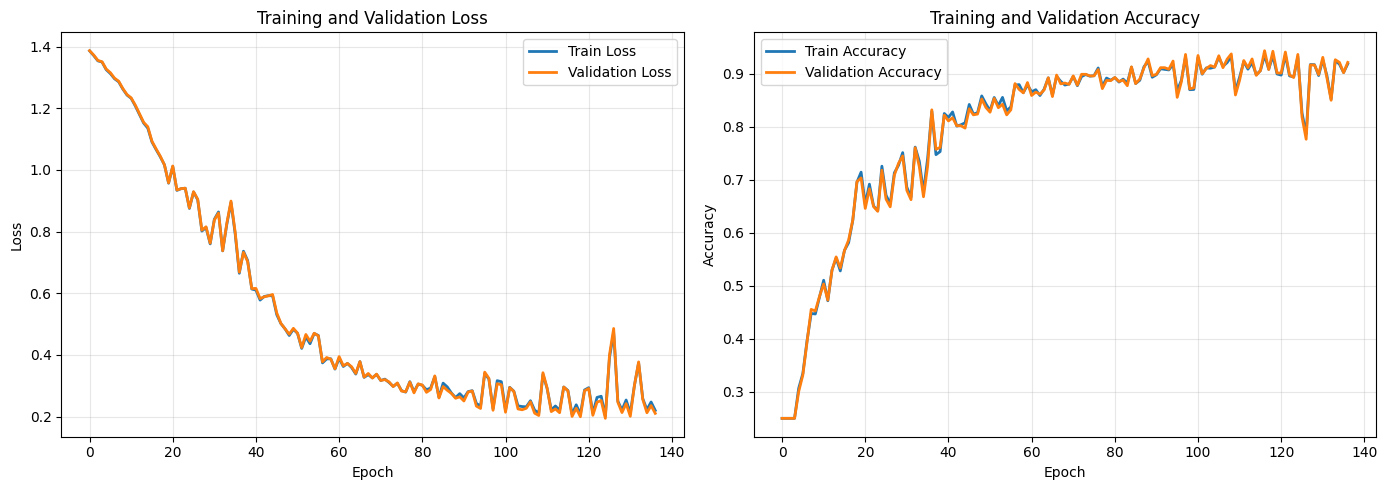

In [20]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(train_accuracies, label='Train Accuracy', linewidth=2)
axes[1].plot(val_accuracies, label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Model Evaluation


In [21]:
# Final evaluation on test set using helper function
print("="*60)
print("Evaluating GraphSAGE on Test Set")
print("="*60)

metrics, test_pred, test_probs = evaluate_graphsage_on_test(
    model=model,
    train_features=data_train.x,
    edge_index_np=edge_index_train,
    X_test_scaled=X_test_scaled,
    y_test=y_test,
    device=device,
    k_neighbors=10
)

test_true = y_test

test_accuracy = metrics['accuracy']
test_precision = metrics['precision']
test_recall = metrics['recall']
test_f1 = metrics['f1']

print("=" * 60)
print("GNN MODEL RESULTS")
print("=" * 60)
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(test_true, test_pred, 
                          target_names=le_triage.classes_, 
                          zero_division=0))


Evaluating GraphSAGE on Test Set
GNN MODEL RESULTS
Test Accuracy:  0.8281
Test Precision: 0.9100
Test Recall:    0.8281
Test F1-Score: 0.8551

Classification Report:
              precision    recall  f1-score   support

       green       0.62      0.95      0.75       132
      orange       0.37      0.75      0.49       104
         red       0.21      0.69      0.32        39
      yellow       0.98      0.83      0.90      1691

    accuracy                           0.83      1966
   macro avg       0.55      0.80      0.62      1966
weighted avg       0.91      0.83      0.86      1966



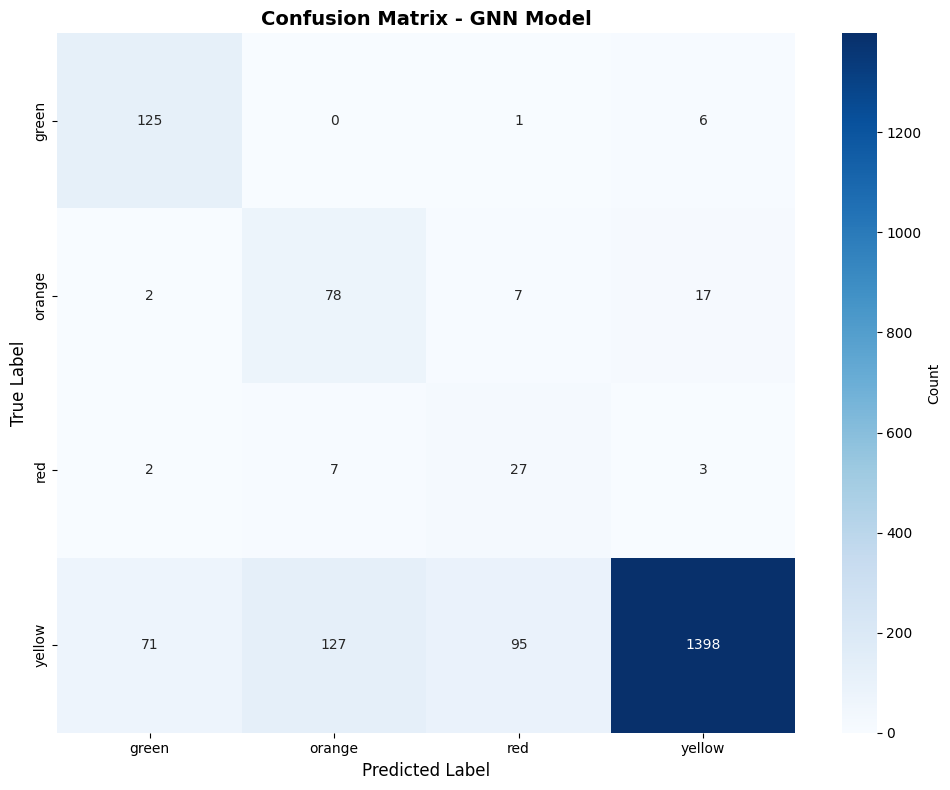

In [22]:
# Confusion Matrix
cm = confusion_matrix(test_true, test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_triage.classes_, 
            yticklabels=le_triage.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - GNN Model', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


## 8. Baseline Methods Comparison

Following the paper, we compare GNN results with traditional machine learning baselines.


In [23]:
# DIAGNOSTIC: Check for data leakage in features
print("="*80)
print("DIAGNOSTIC: Checking for Data Leakage")
print("="*80)

# Check if any feature has perfect correlation with target
from scipy.stats import chi2_contingency
from scipy import stats

print("\n1. Checking feature correlations with target:")
feature_importance_check = {}
for i, col in enumerate(all_numerical_cols):
    if i < len(X_train_scaled[0]):
        # For numerical features, check correlation
        if col not in ['Residence_type_encoded', 'smoking_status_encoded']:
            corr, p_value = stats.pearsonr(X_train_scaled[:, i], y_train)
            feature_importance_check[col] = {'correlation': abs(corr), 'p_value': p_value}
        else:
            # For categorical, check chi-square
            contingency = pd.crosstab(X_train_scaled[:, i], y_train)
            chi2, p_value, dof, expected = chi2_contingency(contingency)
            feature_importance_check[col] = {'chi2': chi2, 'p_value': p_value}

# Sort by importance
sorted_features = sorted(feature_importance_check.items(), 
                        key=lambda x: x[1].get('correlation', x[1].get('chi2', 0)), 
                        reverse=True)

print("\nTop 5 most predictive features:")
for feat, stats_dict in sorted_features[:5]:
    if 'correlation' in stats_dict:
        print(f"  {feat}: correlation={stats_dict['correlation']:.4f}, p={stats_dict['p_value']:.2e}")
    else:
        print(f"  {feat}: chi2={stats_dict['chi2']:.2f}, p={stats_dict['p_value']:.2e}")

# Check for perfect separability
print("\n2. Checking for perfect class separability:")
unique_combinations = {}
for i in range(min(1000, len(X_train_scaled))):  # Sample check
    feat_tuple = tuple(X_train_scaled[i, :5].round(2))  # Check first 5 features
    label = y_train[i]
    if feat_tuple not in unique_combinations:
        unique_combinations[feat_tuple] = label
    elif unique_combinations[feat_tuple] != label:
        unique_combinations[feat_tuple] = 'mixed'

perfect_sep = sum(1 for v in unique_combinations.values() if v != 'mixed')
print(f"  Perfect separability ratio: {perfect_sep/len(unique_combinations):.2%}")


print("\n3. Checking train vs test distribution:")
print(f"  Train mean: {X_train_scaled.mean(axis=0)[:3]}")
print(f"  Test mean: {X_test_scaled.mean(axis=0)[:3]}")
print(f"  Difference: {abs(X_train_scaled.mean(axis=0) - X_test_scaled.mean(axis=0))[:3]}")
print("="*80)


DIAGNOSTIC: Checking for Data Leakage

1. Checking feature correlations with target:

Top 5 most predictive features:
  smoking_status_encoded: chi2=14073.71, p=1.39e-198
  Residence_type_encoded: chi2=9692.98, p=6.27e-87
  plasma glucose: correlation=0.6862, p=0.00e+00
  hypertension: correlation=0.1342, p=2.69e-64
  chest pain type: correlation=0.1280, p=1.12e-58

2. Checking for perfect class separability:
  Perfect separability ratio: 100.00%

3. Checking train vs test distribution:
  Train mean: [0.42127856 0.66570403 0.3106006 ]
  Test mean: [0.54731377 0.53814852 0.14165819]
  Difference: [0.12603521 0.12755551 0.16894241]


In [24]:
# Baseline 1: Random Forest (AGGRESSIVE FIX: Prevent overfitting)
print("="*60)
print("Training Random Forest with STRICT regularization")
print("="*60)
print("Note: 100% accuracy suggests overfitting or data leakage")

# Very strict regularization to prevent overfitting
rf_model = RandomForestClassifier(
    n_estimators=50,  # Reduced trees
    random_state=42, 
    max_depth=5,  # Very shallow trees
    min_samples_split=50,  # Require many samples to split
    min_samples_leaf=20,  # Require many samples per leaf
    max_features='sqrt',  # Limit features per split
    class_weight='balanced',  # Handle class imbalance
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Check training accuracy vs test accuracy
rf_train_pred = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_pred = rf_model.predict(X_test)

print(f"Random Forest Training Accuracy: {rf_train_acc:.4f}")
print(f"Random Forest Test Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
if rf_train_acc > 0.99 and accuracy_score(y_test, rf_pred) < 0.95:
    print("⚠️  WARNING: High train accuracy but lower test accuracy = OVERFITTING")
elif rf_train_acc > 0.99 and accuracy_score(y_test, rf_pred) > 0.99:
    print("⚠️  WARNING: Both train and test are perfect - possible data leakage!")
print("="*60)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average='weighted', zero_division=0)

print("Random Forest Results:")
print(f"  Accuracy:  {rf_accuracy:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall:    {rf_recall:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")
print()


Training Random Forest with STRICT regularization
Note: 100% accuracy suggests overfitting or data leakage
Random Forest Training Accuracy: 0.9863
Random Forest Test Accuracy: 0.9791
Random Forest Results:
  Accuracy:  0.9791
  Precision: 0.9830
  Recall:    0.9791
  F1-Score:  0.9803



In [25]:
# Baseline 2: Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', solver='lbfgs')
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted', zero_division=0)
lr_recall = recall_score(y_test, lr_pred, average='weighted', zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, average='weighted', zero_division=0)

print("Logistic Regression Results:")
print(f"  Accuracy:  {lr_accuracy:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall:    {lr_recall:.4f}")
print(f"  F1-Score:  {lr_f1:.4f}")
print()


Training Logistic Regression...
Logistic Regression Results:
  Accuracy:  0.8952
  Precision: 0.9445
  Recall:    0.8952
  F1-Score:  0.9100



In [26]:
# Comparison Table
comparison_results = {
    'Model': ['Graph Neural Network', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [test_accuracy, rf_accuracy, lr_accuracy],
    'Precision': [test_precision, rf_precision, lr_precision],
    'Recall': [test_recall, rf_recall, lr_recall],
    'F1-Score': [test_f1, rf_f1, lr_f1]
}

comparison_df = pd.DataFrame(comparison_results)
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)


MODEL COMPARISON
               Model  Accuracy  Precision   Recall  F1-Score
Graph Neural Network  0.828077   0.909964 0.828077  0.855051
       Random Forest  0.979145   0.982951 0.979145  0.980301
 Logistic Regression  0.895219   0.944467 0.895219  0.909994


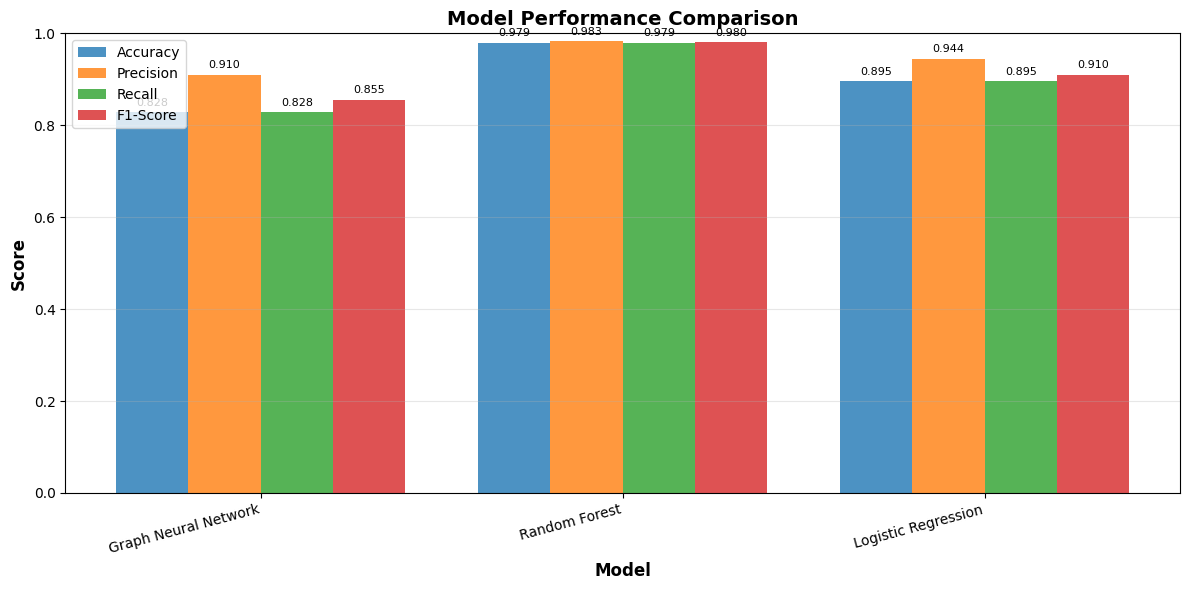

In [27]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, metric in enumerate(metrics):
    offset = (i - 1.5) * width
    ax.bar(x + offset, comparison_df[metric], width, label=metric, alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.legend(loc='upper left')
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, model in enumerate(comparison_df['Model']):
    for j, metric in enumerate(metrics):
        offset = (j - 1.5) * width
        value = comparison_df.loc[i, metric]
        ax.text(i + offset, value + 0.01, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
